In [1]:
import os
os.makedirs('results/eda_visualizations', exist_ok=True)
print("Folder created!")

Folder created!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('BankChurners.csv')

# Drop identifier column and separate features from target
X = df.drop(columns=['CLIENTNUM', 'Attrition_Flag'])
y = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Stratified Train/Test split first to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 8101, Testing samples: 2026


In [3]:
# Select continuous numerical columns with large differences in magnitude
numeric_features = ['Credit_Limit', 'Total_Trans_Amt', 'Avg_Utilization_Ratio']

# Initialize StandardScaler (Z-score normalization)
scaler = StandardScaler()

# Fit strictly on X_train to prevent leakage, then transform both splits
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# Print verification statistics
print("Scaled Training Features (Mean ~ 0, Std ~ 1):")
print(X_train_scaled[numeric_features].describe().round(2))

Scaled Training Features (Mean ~ 0, Std ~ 1):
       Credit_Limit  Total_Trans_Amt  Avg_Utilization_Ratio
count       8101.00          8101.00                8101.00
mean           0.00             0.00                   0.00
std            1.00             1.00                   1.00
min           -0.79            -1.14                  -1.00
25%           -0.67            -0.66                  -0.91
50%           -0.45            -0.15                  -0.36
75%            0.26             0.10                   0.83
max            2.87             4.01                   2.61


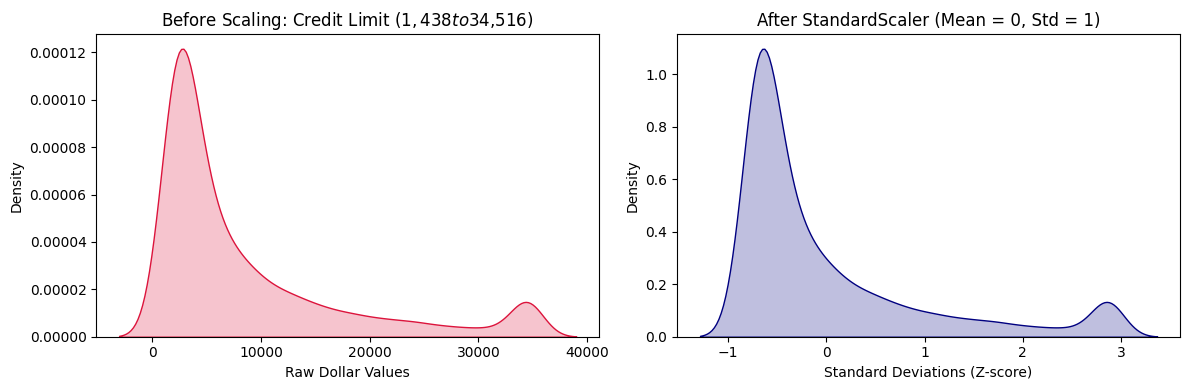

Plot successfully saved to: results/eda_visualizations/IT25102093_scaling_comparison.png


In [4]:
# Create the required before vs. after comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before scaling
sns.kdeplot(X_train['Credit_Limit'], ax=axes[0], color='crimson', fill=True)
axes[0].set_title('Before Scaling: Credit Limit ($1,438 to $34,516)')
axes[0].set_xlabel('Raw Dollar Values')
axes[0].set_ylabel('Density')

# After scaling
sns.kdeplot(X_train_scaled['Credit_Limit'], ax=axes[1], color='navy', fill=True)
axes[1].set_title('After StandardScaler (Mean = 0, Std = 1)')
axes[1].set_xlabel('Standard Deviations (Z-score)')
axes[1].set_ylabel('Density')

plt.tight_layout()

# Save image file to deliverable directory
plot_path = 'results/eda_visualizations/IT25102093_scaling_comparison.png'
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"Plot successfully saved to: {plot_path}")